# Observing conditions vs. mirror/air temperature difference (`telemetry_mining` rewrite)

Rewrite of `obs_conditions.ipynb` using the `telemetry_mining` package. The original
scanned almost a full year night-by-night (`DOSlib.util.find_exposures` per night, then
a manual `fitsio` header read per exposure) to build one row per exposure. `select_exposures`
replaces both steps with a single bulk primitive: one SQL query against `exposure.exposure`
for the candidate list, then one header read per candidate exposure for the requested
keywords -- no DOSlib, no manual path-building.

Main question (dome seeing): does a temperature difference between the primary mirror and
the air above it (`DELTAT = PMIRTEMP - TAIRTEMP`) correlate with degraded seeing/throughput
(`ETCSEENG`/`ETCFRACP`)? The original notebook is left untouched for comparison.

In [ ]:
import os
import sys

# Add telemetry_mining to the path. Point DOS_TELEMETRY_MINING_DIR at your own
# checkout (svn co https://desi.lbl.gov/svn/code/online/telemetry_mining/trunk);
# defaults to the maintainer's checkout at NERSC.
TM_DIR = os.getenv("DOS_TELEMETRY_MINING_DIR", os.path.expanduser("~/telemetry_mining-trunk/src"))
sys.path.insert(0, TM_DIR)

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from telemetry_mining import select_exposures

## Candidate exposures + header keywords

The original's full history was `year=2024`, days 0-279 (almost the entire year) --
tens of thousands of exposures, each needing a FITS header open. `NIGHT_MIN`/`NIGHT_MAX`
below default to a recent, manageable window for an interactive first run; widen back to
the original's range to reproduce its full history.

**Real finding, not hypothetical**: even in this narrow, recent window, one exposure's
FITS file was missing on disk (`select_exposures` raised `OSError` opening its header).
`select_exposures` doesn't skip an exposure if resolving one of its column specs fails --
it raises, by design (see `API.md`) -- whereas the original silently skipped such exposures
via a broad `try/except` around the whole FITS open. Below, each keyword is a callable that
opens the header once per exposure (caching the result, including the "missing" case) and
falls back to `None` per key, matching the original's graceful-degradation behavior. Rows
where the header couldn't be opened at all end up all-`None` and get dropped by the
downselect step below (`EXPTIME`/`PROGRAM` both `None` fails the filters) -- close enough
to "skipped" for this notebook's purposes, without silently swallowing errors elsewhere in
the package.

In [2]:
NIGHT_MIN = 20260601  # widen to 20240101 to reproduce the original's ~280-day history
NIGHT_MAX = 20260714  # widen to 20241007

keywords = ['PMIRTEMP', 'TAIRTEMP', 'ETCFRACP', 'PMSEEING', 'ETCSEENG', 'AIRMASS', 'ROTOFFST', 'ROTRATE',
            'ROTENBLD', 'POSRMS', 'TURBRMS','SKYLEVEL','MOUNTAZ', 'MOUNTEL','MOUNTHA','SKYDEC','SKYRA',
            'MNTOFFD','MNTOFFR','GUIDOFFD','GUIDOFFR','TRUSTEMP','EXPTIME','PROGRAM']

_header_cache = {}
def _safe_header(exp):
    if exp.expid not in _header_cache:
        try:
            _header_cache[exp.expid] = exp.header
        except Exception as e:
            print(f'Skipping exposure {exp.expid}: {e}')
            _header_cache[exp.expid] = {}
    return _header_cache[exp.expid]

df = select_exposures(
    "sequence = %s and night between %s and %s",
    columns={k: (lambda exp, k=k: _safe_header(exp).get(k)) for k in keywords},
    params=('DESI', NIGHT_MIN, NIGHT_MAX),
)
df = df.set_index('EXPID')
print(f'{len(df)} exposures')
df.head()

Skipping exposure 354406: FITSIO status = 104: could not open the named file
failed to find or open the following file: (ffopen)
/global/cfs/cdirs/desi/spectro/data/20260601/00354406/desi-00354406.fits.fz



Skipping exposure 354407: FITSIO status = 104: could not open the named file
failed to find or open the following file: (ffopen)
/global/cfs/cdirs/desi/spectro/data/20260601/00354407/desi-00354407.fits.fz



Skipping exposure 357650: FITSIO status = 104: could not open the named file
failed to find or open the following file: (ffopen)
/global/cfs/cdirs/desi/spectro/data/20260621/00357650/desi-00357650.fits.fz



Skipping exposure 356353: FITSIO status = 104: could not open the named file
failed to find or open the following file: (ffopen)
/global/cfs/cdirs/desi/spectro/data/20260613/00356353/desi-00356353.fits.fz



Skipping exposure 357806: FITSIO status = 104: could not open the named file
failed to find or open the following file: (ffopen)
/global/cfs/cdirs/desi/spectro/data/20260622/00357806/desi-00357806.fits.fz

Skipping exposure 357807: FITSIO status = 104: could not open the named file
failed to find or open the following file: (ffopen)
/global/cfs/cdirs/desi/spectro/data/20260622/00357807/desi-00357807.fits.fz



...

Skipping exposure 361281: FITSIO status = 104: could not open the named file
failed to find or open the following file: (ffopen)
/global/cfs/cdirs/desi/spectro/data/20260714/00361281/desi-00361281.fits.fz



Skipping exposure 355588: FITSIO status = 104: could not open the named file
failed to find or open the following file: (ffopen)
/global/cfs/cdirs/desi/spectro/data/20260608/00355588/desi-00355588.fits.fz



Skipping exposure 358842: FITSIO status = 104: could not open the named file
failed to find or open the following file: (ffopen)
/global/cfs/cdirs/desi/spectro/data/20260628/00358842/desi-00358842.fits.fz



Skipping exposure 360813: FITSIO status = 104: could not open the named file
failed to find or open the following file: (ffopen)
/global/cfs/cdirs/desi/spectro/data/20260710/00360813/desi-00360813.fits.fz

Skipping exposure 359689: FITSIO status = 104: could not open the named file
failed to find or open the following file: (ffopen)
/global/cfs/cdirs/desi/spectro/data/20260703/00359689/desi-00359689.fits.fz

831 exposures


,NIGHT,PMIRTEMP,TAIRTEMP,ETCFRACP,PMSEEING,ETCSEENG,AIRMASS,ROTOFFST,ROTRATE,ROTENBLD,...,MOUNTHA,SKYDEC,SKYRA,MNTOFFD,MNTOFFR,GUIDOFFD,GUIDOFFR,TRUSTEMP,EXPTIME,PROGRAM
EXPID,,,,,,,,,,,,,,,,,,,,,
354406,20260601,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
354405,20260601,13.713,17.670,0.361803,1.5281,1.5399,1.947813,-26.3,0.491,True,...,-4.800323,-27.07119,202.414821,59.31,-4.32,0.007693,0.020250,19.267,604.9580,BACKUP
354407,20260601,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
354408,20260601,14.187,17.625,0.341731,1.4409,1.4913,1.906730,-29.6,0.524,True,...,-10.092099,-25.71956,212.041350,60.37,-5.36,0.017322,0.087735,19.233,603.4375,BACKUP
354409,20260601,14.438,17.748,0.427355,1.3728,1.3619,1.031922,9.9,0.520,True,...,-8.090282,44.86830,213.753842,36.38,-1.76,-0.046341,0.021801,19.100,397.2827,BACKUP


In [3]:
# convert data to a pandas dataframe
df['DELTAT']= df['PMIRTEMP'] - df['TAIRTEMP']


In [4]:
# create backup DF
df_orig = df.copy()

In [5]:
# Down select data frame
# for example with exptime > 100s or select a program
print(f'Original data set includes {len(df_orig)} records')

# require minimum exposure time
df = df_orig[df_orig.EXPTIME>100.0]

# require program == DARK
df = df[df.PROGRAM=="DARK"]

print(f'Downselected data set includes {len(df)} records')
      

Original data set includes 831 records
Downselected data set includes 94 records


12 23


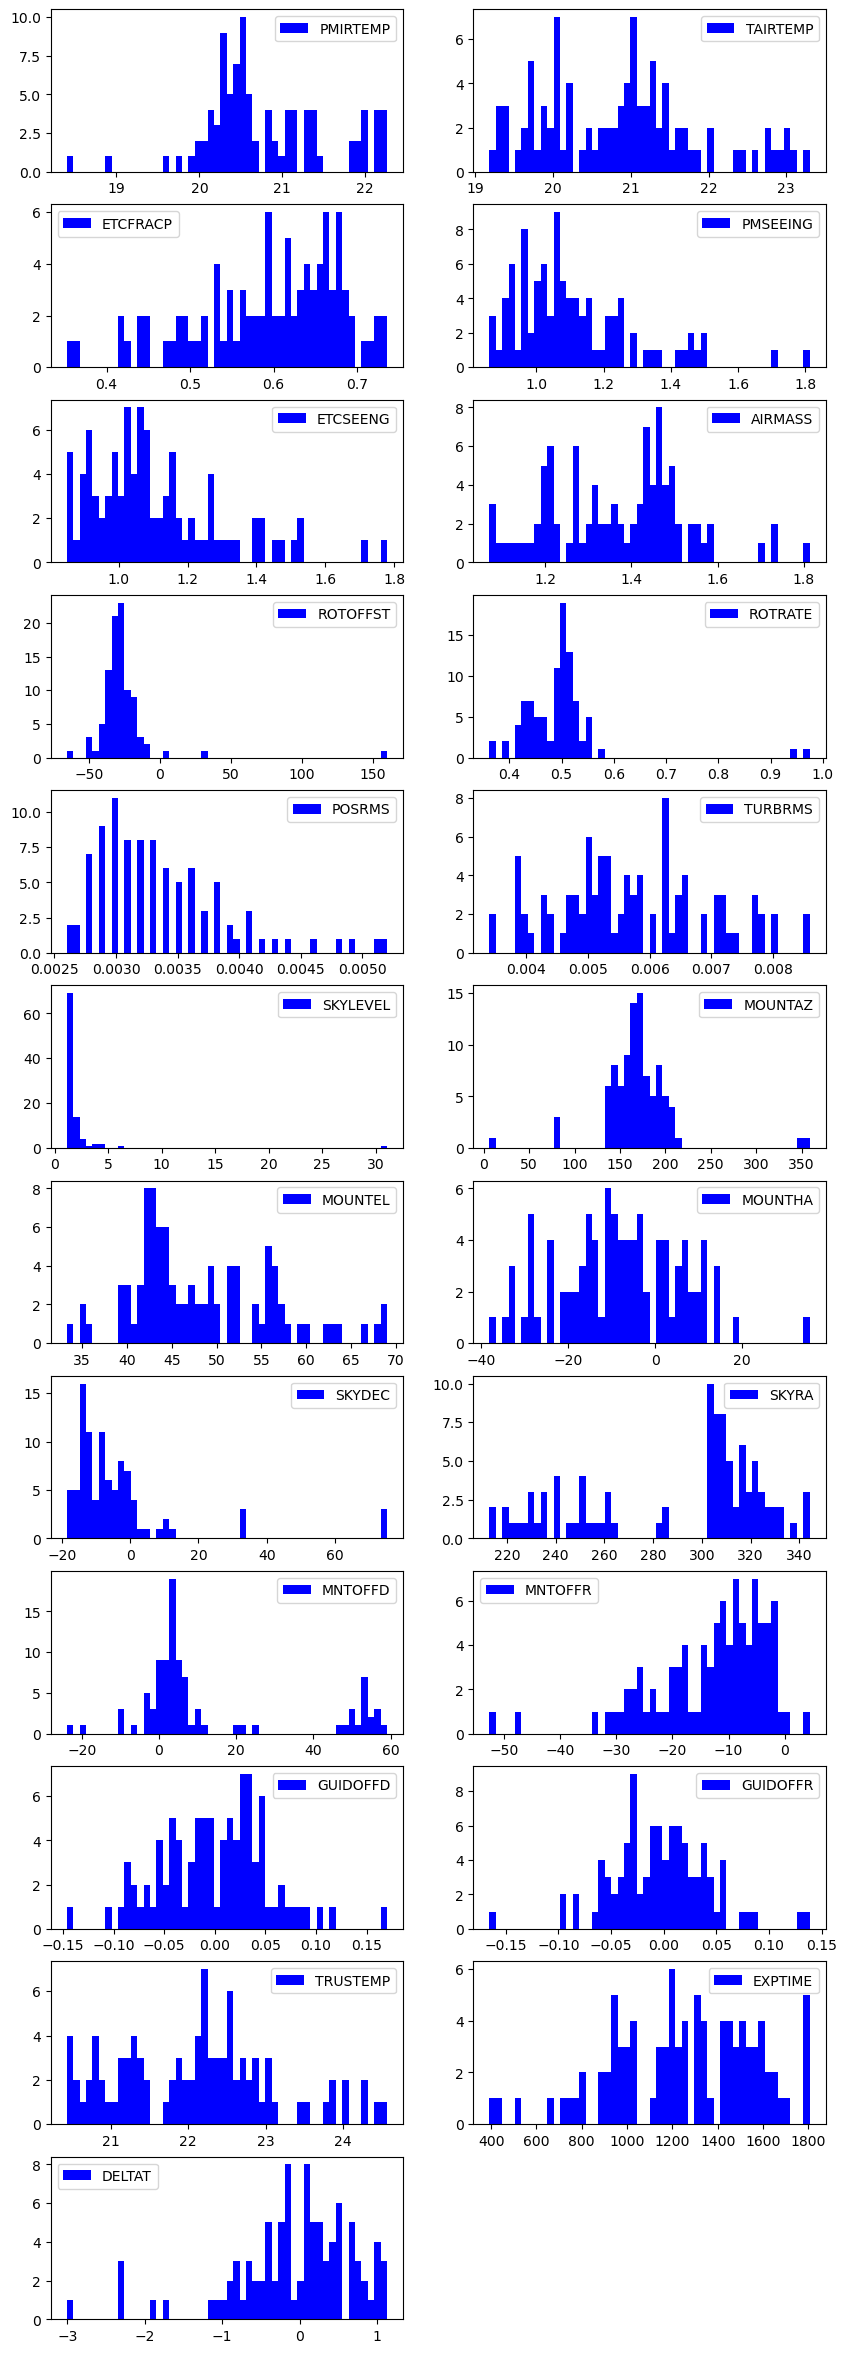

In [6]:
# some initial analysis
variables = list(keywords)
variables.append('DELTAT')
variables.remove('PROGRAM')
variables.remove('ROTENBLD')
yf = int(len(variables)/2)+1
print(yf,len(variables))
fig = plt.figure(figsize=(10,yf*2.5))
index = 1
for key in variables:
    plt.subplot(yf,2,index)
    index += 1
    try:
        plt.hist(df[key],bins=50,histtype='bar',color='b',label=key)
        plt.legend()
    except Exception as e:
        print(str(e))

plt.show()

    


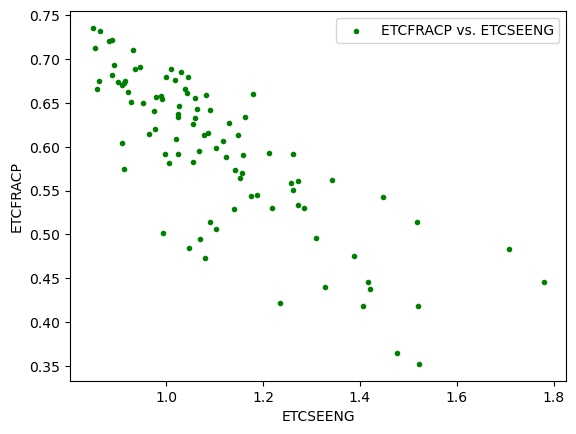

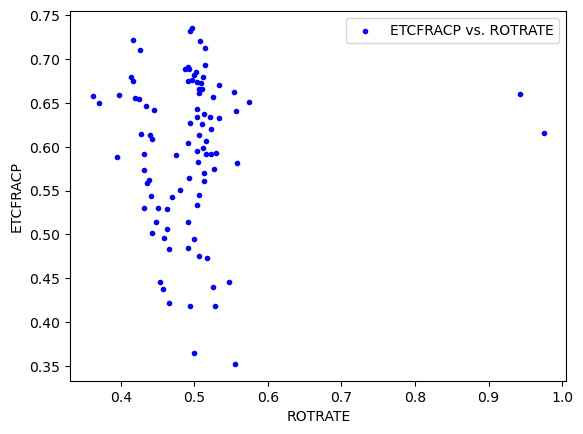

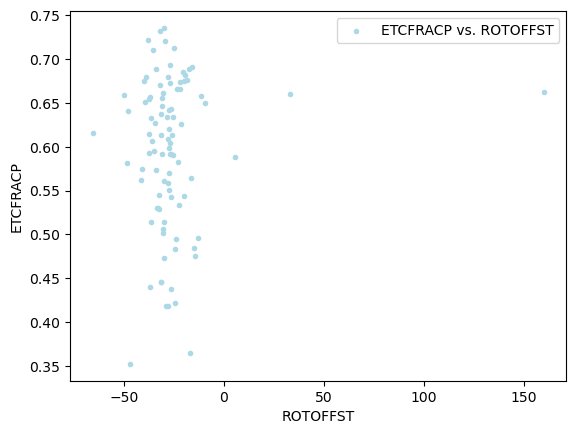

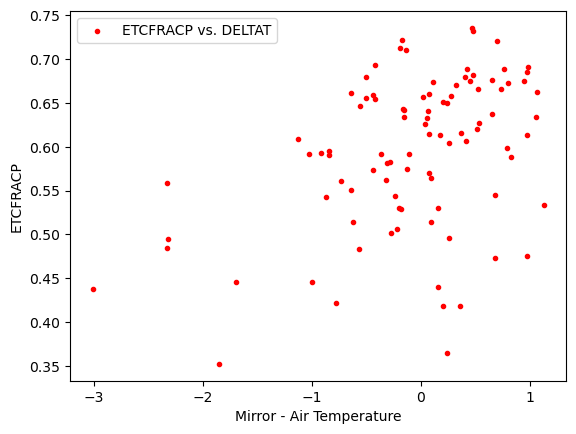

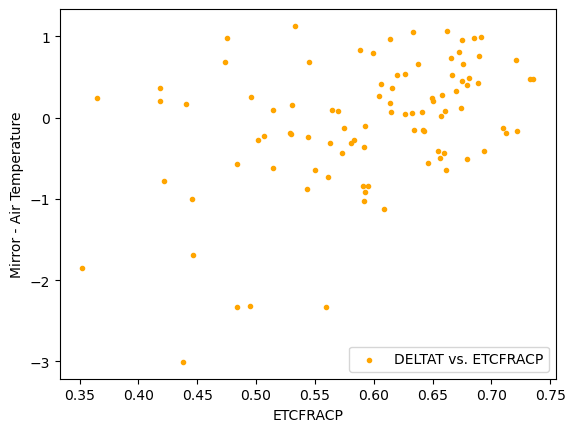

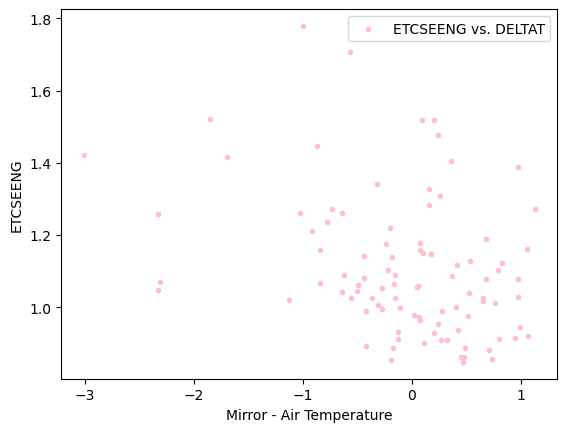

In [7]:
# some correlation studies
pairs = [('ETCSEENG','ETCFRACP','g'),('ROTRATE','ETCFRACP','b'),('ROTOFFST','ETCFRACP','lightblue'),('DELTAT','ETCFRACP','r'),('ETCFRACP','DELTAT','orange'),('DELTAT','ETCSEENG','pink')]
for x,y,c in pairs:
    plt.scatter(df[x],df[y],label = f'{y} vs. {x}',color=c,marker='.')
    if 'DELTAT' in y:
        y = 'Mirror - Air Temperature'
    if 'DELTAT' in x:
        x = 'Mirror - Air Temperature'
    plt.ylabel(y)
    plt.xlabel(x)
    plt.legend()
    plt.show()


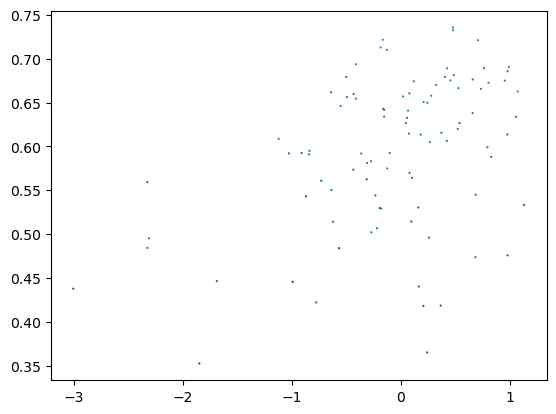

In [8]:
# 3D scatter
x='DELTAT'
y='ETCFRACP'
s='ETCSEENG'
c='g'
plt.scatter(df[x],df[y],s=df[s],label = f'{y} vs. {x}',color=c,marker='.')

In [9]:
import matplotlib.cm as cm
from scipy.ndimage import gaussian_filter


def create_map(x, y, s, bins=250):
    heatmap, xedges, yedges = np.histogram2d(x, y, bins=bins)
    heatmap = gaussian_filter(heatmap, sigma=s)

    extent = [xedges[0], xedges[-1], yedges[0], yedges[-1]]
    return heatmap.T, extent

def plot_map(map, extent):
    plt.imshow(map,  origin='lower', cmap=cm.jet, extent=extent,aspect='auto')



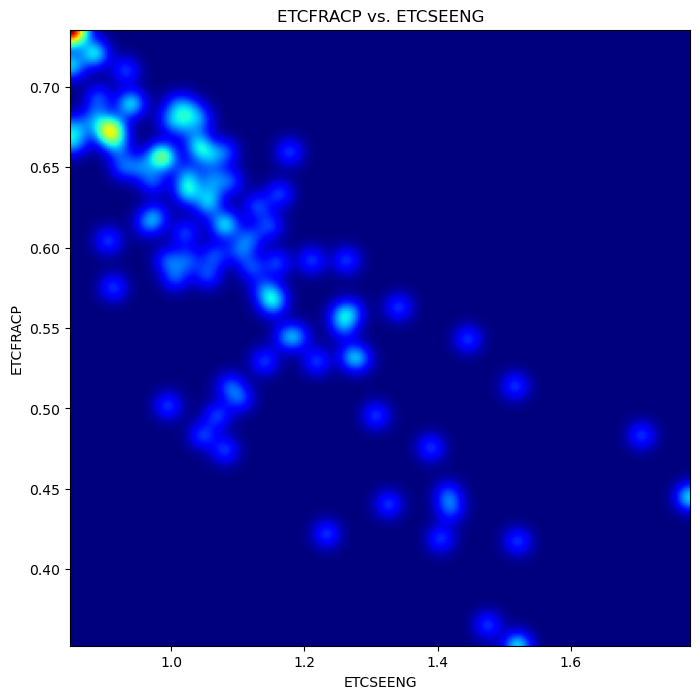

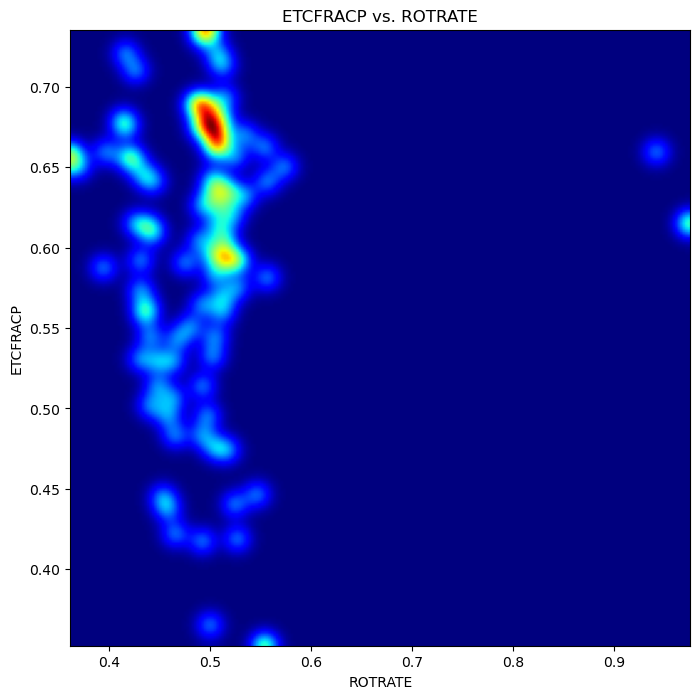

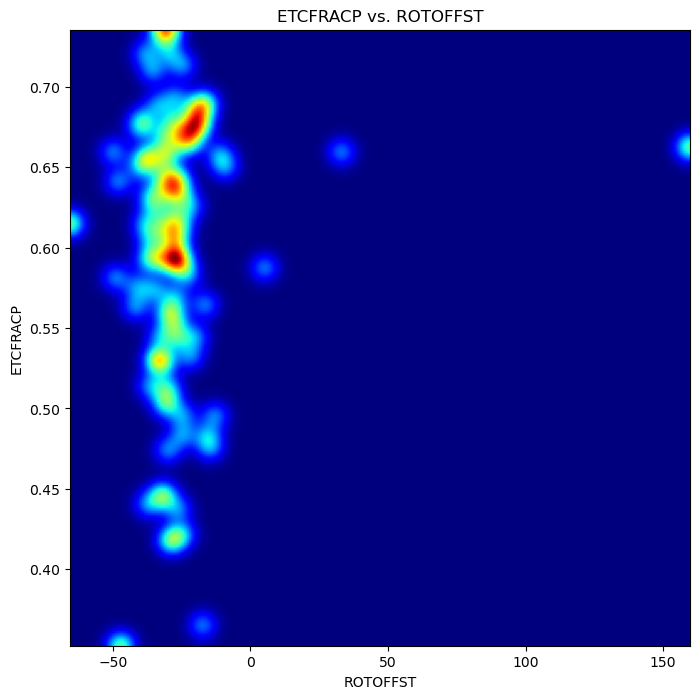

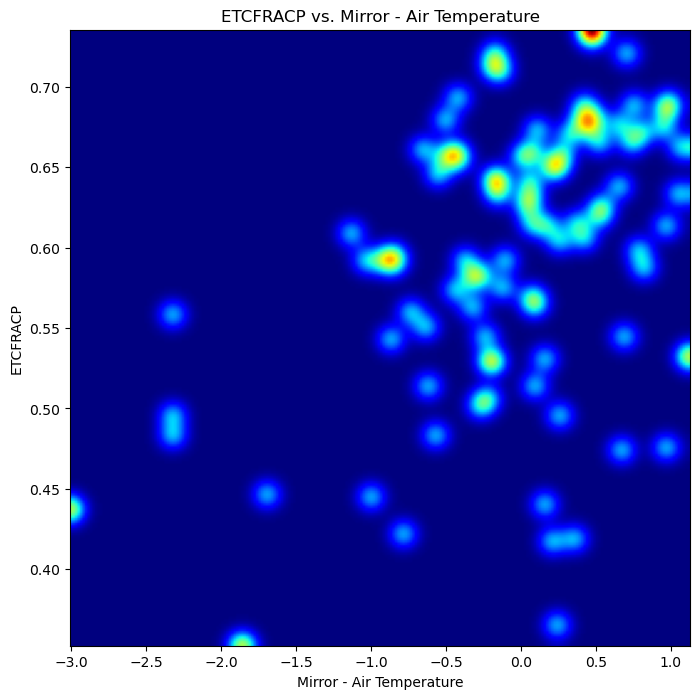

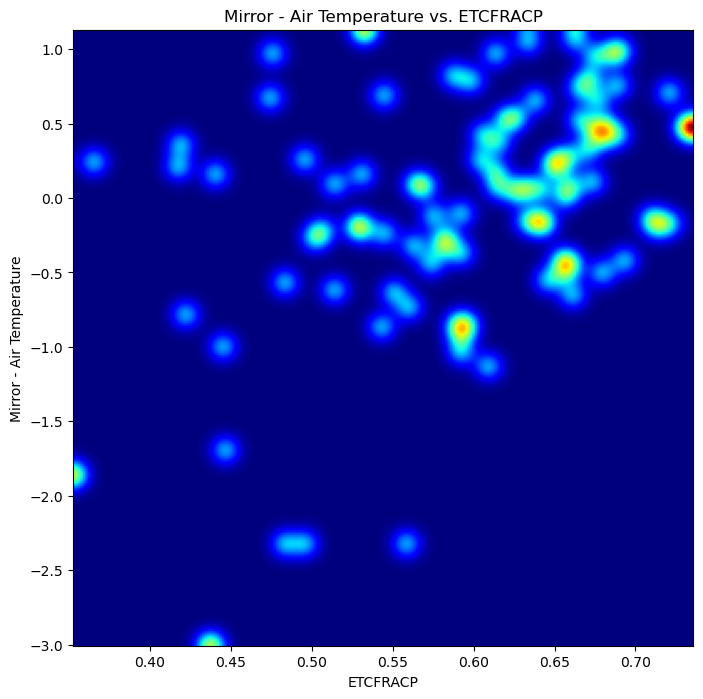

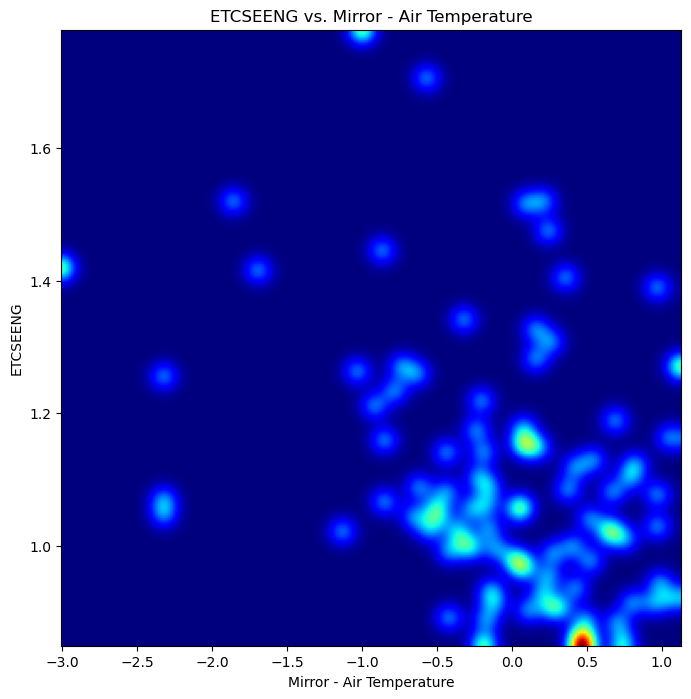

In [10]:
# now as heatmaps
pairs = [('ETCSEENG','ETCFRACP','g'),('ROTRATE','ETCFRACP','b'),('ROTOFFST','ETCFRACP','lightblue'),('DELTAT','ETCFRACP','r'),('ETCFRACP','DELTAT','orange'),('DELTAT','ETCSEENG','pink')]
#smoothing filter
sigma = 4

for x,y,c in pairs:
    ly=df[y].values
    lx=df[x].values
    idx = (~np.isnan(lx+ly))
    lxx = lx[idx]
    lyy = ly[idx]
    map, extent = create_map(lxx,lyy,sigma)
    fig = plt.figure(figsize=(8,8))
    plot_map(map,extent)
    if 'DELTAT' in y:
        y = 'Mirror - Air Temperature'
    if 'DELTAT' in x:
        x = 'Mirror - Air Temperature'
    plt.ylabel(y)
    plt.xlabel(x)
    plt.title(f'{y} vs. {x}')
    plt.show()


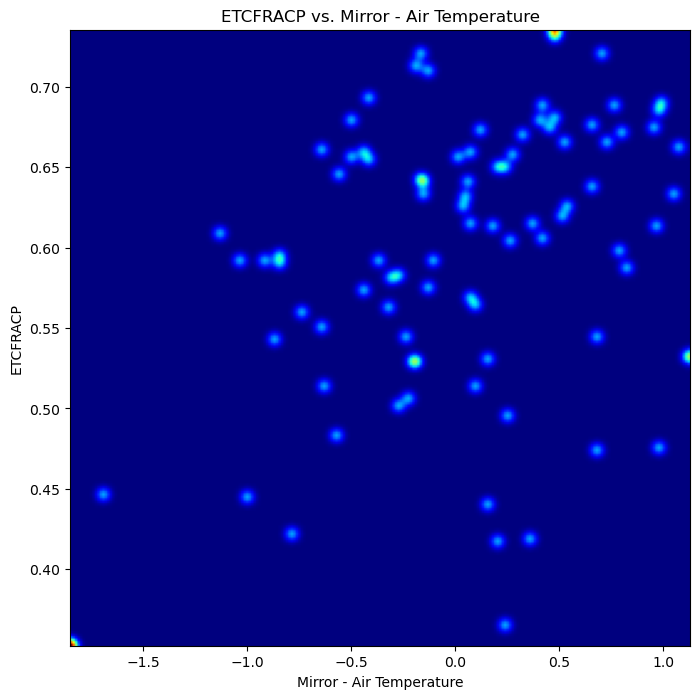

In [11]:
# now as heatmaps
pairs = [('DELTAT','ETCFRACP','pink')]
#smoothing filter
sigma = 2
# reduce range
dff = df[df['DELTAT'].between(-2.0,3.0,inclusive='both')]
dff = dff[dff['ETCFRACP'].between(0.2,1.0,inclusive='both')]
         
for x,y,c in pairs:
    ly=dff[y].values
    lx=dff[x].values
    idx = (~np.isnan(lx+ly))
    lxx = lx[idx]
    lyy = ly[idx]
    map, extent = create_map(lxx,lyy,sigma)
    fig = plt.figure(figsize=(8,8))
    plot_map(map,extent)
    if 'DELTAT' in y:
        y = 'Mirror - Air Temperature'
    if 'DELTAT' in x:
        x = 'Mirror - Air Temperature'
    plt.ylabel(y)
    plt.xlabel(x)
    plt.title(f'{y} vs. {x}')
    plt.show()

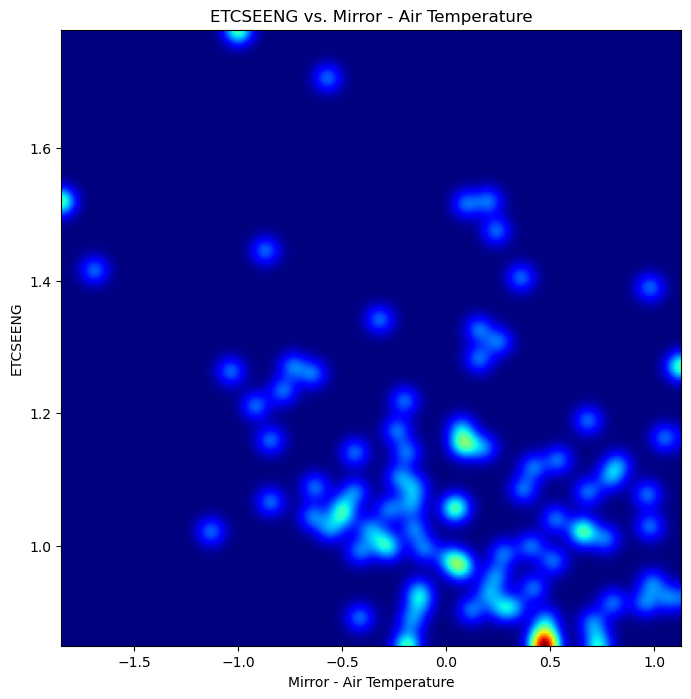

In [12]:
# now as heatmaps
pairs = [('DELTAT','ETCSEENG','pink')]
#smoothing filter
sigma = 4
# reduce range
dff = df[df['DELTAT'].between(-2.0,3.0,inclusive='both')]
dff = dff[dff['ETCSEENG'].between(0.5,2.0,inclusive='both')]
         
for x,y,c in pairs:
    ly=dff[y].values
    lx=dff[x].values
    idx = (~np.isnan(lx+ly))
    lxx = lx[idx]
    lyy = ly[idx]
    map, extent = create_map(lxx,lyy,sigma)
    fig = plt.figure(figsize=(8,8))
    plot_map(map,extent)
    if 'DELTAT' in y:
        y = 'Mirror - Air Temperature'
    if 'DELTAT' in x:
        x = 'Mirror - Air Temperature'
    plt.ylabel(y)
    plt.xlabel(x)
    plt.title(f'{y} vs. {x}')
    plt.show()

94 83 6


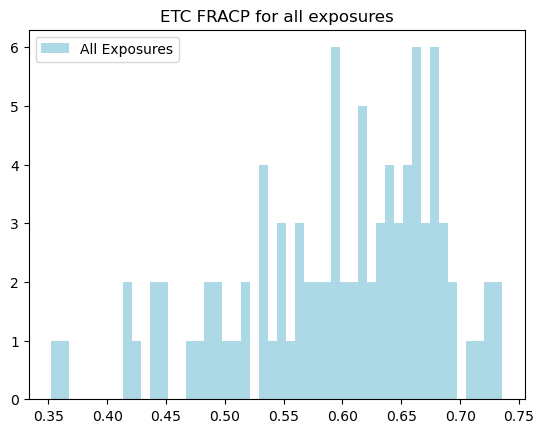

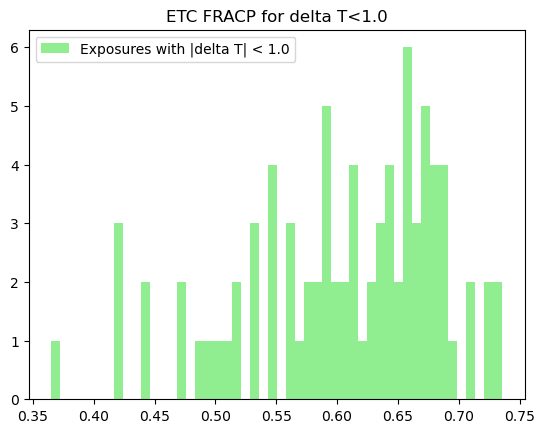

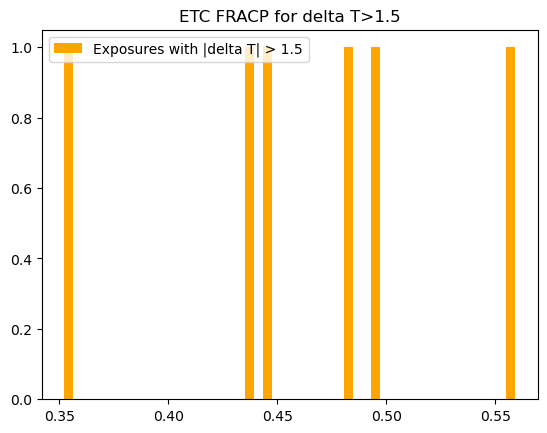

ETC FRACP mean for all exposures 0.595, |delta T|<1.0 0.603, |delta T|>1.0 0.462


In [13]:
# Histogram FFRACP for different DELTA Ts
d1 = list(df['ETCFRACP'].values)
# delta T within 1 degree of zero
d2 = list(df['ETCFRACP'][df['DELTAT'].between(-1.0, 1.0, inclusive='both')].values)
# delta T outside of 1 degree
d3 = list(df['ETCFRACP'][~df['DELTAT'].between(-1.5, 1.5, inclusive='neither')].values)
print(len(d1),len(d2),len(d3))
# Histogram
plt.hist(d1,bins=50,histtype='bar',color='lightblue',label='All Exposures')
plt.legend()
plt.title('ETC FRACP for all exposures')
plt.show()
plt.hist(d2,bins=50,histtype='bar',color='lightgreen',label='Exposures with |delta T| < 1.0')
plt.legend()
plt.title('ETC FRACP for delta T<1.0')
plt.show()
plt.hist(d3,bins=50,histtype='bar',color='orange',label='Exposures with |delta T| > 1.5')
plt.legend()
plt.title('ETC FRACP for delta T>1.5')
plt.show()
# mean values
print(f'ETC FRACP mean for all exposures {np.array(d1).mean():.3f}, |delta T|<1.0 {np.array(d2).mean():.3f}, |delta T|>1.0 {np.array(d3).mean():.3f}')

94 83 6


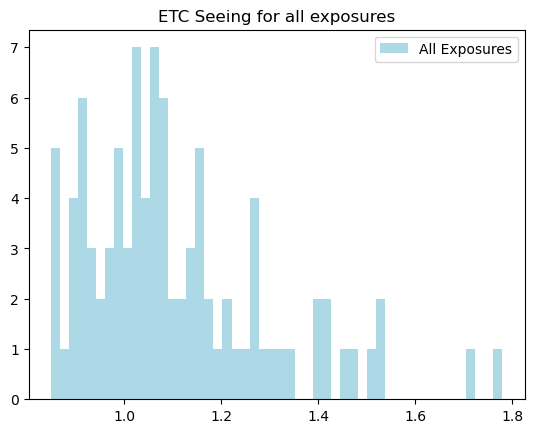

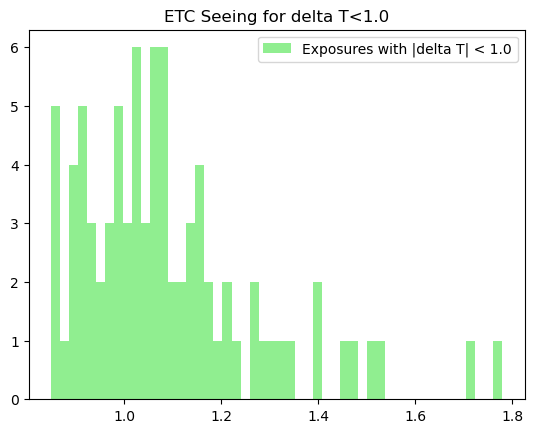

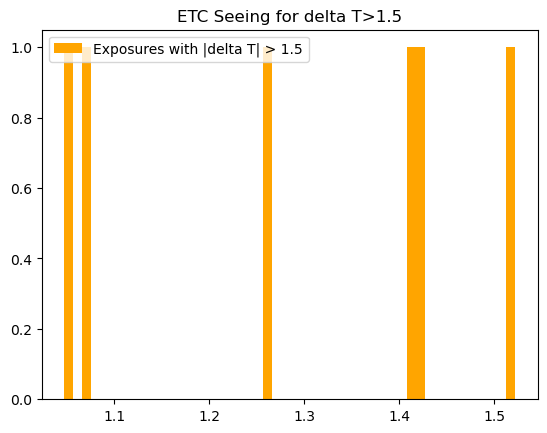

ETC Seeing mean for all exposures 1.108, |delta T|<1.0 1.093, |delta T|>1.0 1.289


In [14]:
# Histogram ETC Seeing for different DELTA Ts
d1 = list(df['ETCSEENG'].values)
# delta T within 1 degree of zero
d2 = list(df['ETCSEENG'][df['DELTAT'].between(-1.0, 1.0, inclusive='both')].values)
# delta T outside of 1 degree
d3 = list(df['ETCSEENG'][~df['DELTAT'].between(-1.5, 1.5, inclusive='neither')].values)
print(len(d1),len(d2),len(d3))
# Histogram
plt.hist(d1,bins=50,histtype='bar',color='lightblue',label='All Exposures')
plt.legend()
plt.title('ETC Seeing for all exposures')
plt.show()
plt.hist(d2,bins=50,histtype='bar',color='lightgreen',label='Exposures with |delta T| < 1.0')
plt.legend()
plt.title('ETC Seeing for delta T<1.0')
plt.show()
plt.hist(d3,bins=50,histtype='bar',color='orange',label='Exposures with |delta T| > 1.5')
plt.legend()
plt.title('ETC Seeing for delta T>1.5')
plt.show()
# mean values
print(f'ETC Seeing mean for all exposures {np.array(d1).mean():.3f}, |delta T|<1.0 {np.array(d2).mean():.3f}, |delta T|>1.0 {np.array(d3).mean():.3f}')

94 83 6


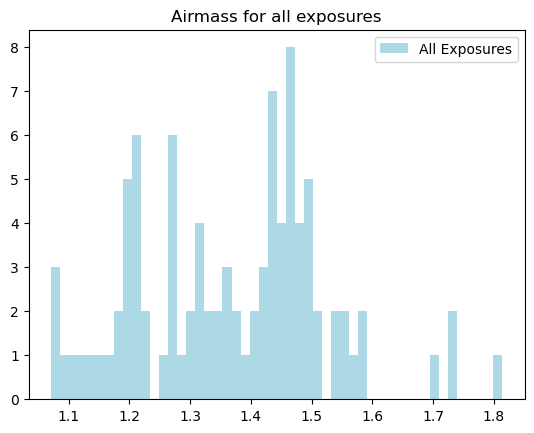

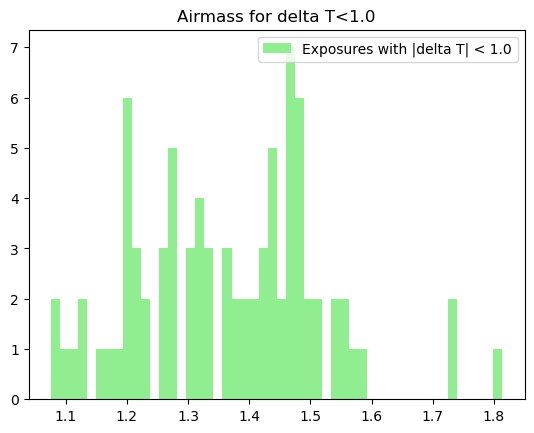

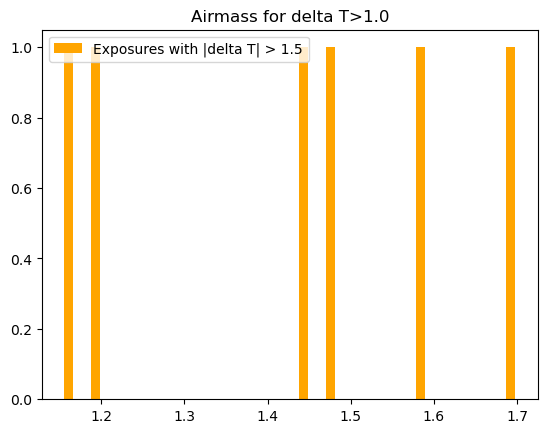

Airmass mean for all exposures 1.368, |delta T|<1.0 1.367, |delta T|>1.0 1.424


In [15]:
# Histogram Airmass for different DELTA Ts
d1 = list(df['AIRMASS'].values)
# delta T within 1 degree of zero
d2 = list(df['AIRMASS'][df['DELTAT'].between(-1.0, 1.0, inclusive='both')].values)
# delta T outside of 1 degree
d3 = list(df['AIRMASS'][~df['DELTAT'].between(-1.5, 1.5, inclusive='neither')].values)
print(len(d1),len(d2),len(d3))
# Histogram
plt.hist(d1,bins=50,histtype='bar',color='lightblue',label='All Exposures')
plt.legend()
plt.title('Airmass for all exposures')
plt.show()
plt.hist(d2,bins=50,histtype='bar',color='lightgreen',label='Exposures with |delta T| < 1.0')
plt.legend()
plt.title('Airmass for delta T<1.0')
plt.show()
plt.hist(d3,bins=50,histtype='bar',color='orange',label='Exposures with |delta T| > 1.5')
plt.legend()
plt.title('Airmass for delta T>1.0')
plt.show()
# mean values
print(f'Airmass mean for all exposures {np.array(d1).mean():.3f}, |delta T|<1.0 {np.array(d2).mean():.3f}, |delta T|>1.0 {np.array(d3).mean():.3f}')

94 0 94


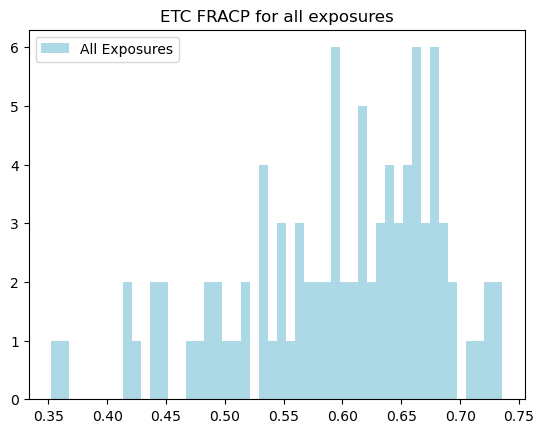

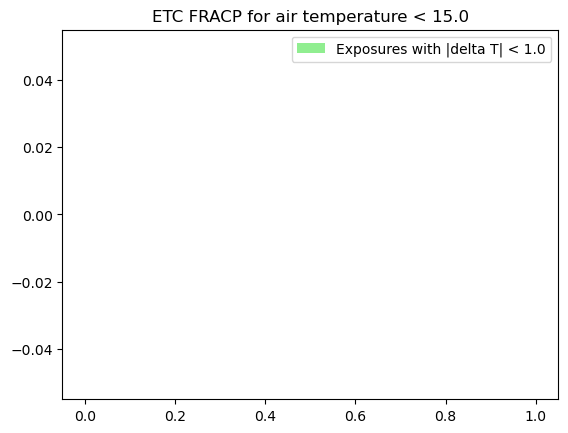

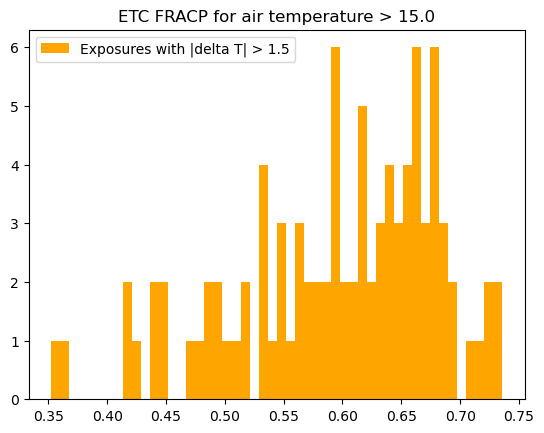

ETC FRACP mean for all exposures 0.595, T_air<15.0 nan, T_ari>1.0 0.595


/tmp/ipykernel_100089/3045058957.py:22: RuntimeWarning: Mean of empty slice.
  print(f'ETC FRACP mean for all exposures {np.array(d1).mean():.3f}, T_air<15.0 {np.array(d2).mean():.3f}, T_ari>1.0 {np.array(d3).mean():.3f}')
/global/common/software/desi/perlmutter/desiconda/20260227-2.3.1/conda/lib/python3.13/site-packages/numpy/_core/_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [16]:
# Histogram FFRACP for different air temperature
d1 = list(df['ETCFRACP'].values)
# Air temperature < 15.0
d2 = list(df['ETCFRACP'][df['TAIRTEMP']<15.0].values)
# Air temperature > 15.0
d3 = list(df['ETCFRACP'][df['TAIRTEMP']>15.0].values)
print(len(d1),len(d2),len(d3))
# Histogram
plt.hist(d1,bins=50,histtype='bar',color='lightblue',label='All Exposures')
plt.legend()
plt.title('ETC FRACP for all exposures')
plt.show()
plt.hist(d2,bins=50,histtype='bar',color='lightgreen',label='Exposures with |delta T| < 1.0')
plt.legend()
plt.title('ETC FRACP for air temperature < 15.0')
plt.show()
plt.hist(d3,bins=50,histtype='bar',color='orange',label='Exposures with |delta T| > 1.5')
plt.legend()
plt.title('ETC FRACP for air temperature > 15.0')
plt.show()
# mean values
print(f'ETC FRACP mean for all exposures {np.array(d1).mean():.3f}, T_air<15.0 {np.array(d2).mean():.3f}, T_ari>1.0 {np.array(d3).mean():.3f}')

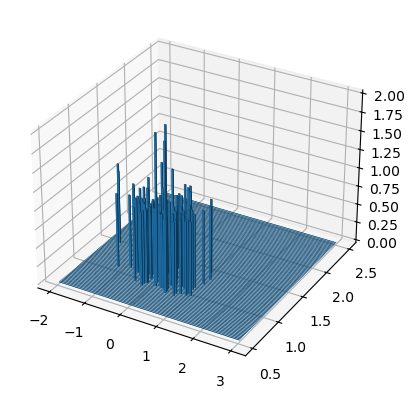

In [17]:
# now as 3D scatter plot

pairs = [('DELTAT','ETCSEENG','pink')]
# reduce range
dff = df[df['DELTAT'].between(-2.0,3.0,inclusive='both')]
dff = dff[dff['ETCSEENG'].between(0.5,2.0,inclusive='both')]
       
for x,y,c in pairs:
    ly=dff[y].values
    lx=dff[x].values
    idx = (~np.isnan(lx+ly))
    lxx = lx[idx]
    lyy = ly[idx]
    fig = plt.figure()
    ax = fig.add_subplot(projection='3d')    
    hist, xedges, yedges = np.histogram2d(lxx, lyy, bins=100,range=[[-2, 3], [0.5, 2.5]])
    # Construct arrays for the anchor positions of the bars.
    xpos, ypos = np.meshgrid(xedges[:-1] + 5/200, yedges[:-1] + 2/200, indexing="ij")
    xpos = xpos.ravel()
    ypos = ypos.ravel()
    zpos = 0

    # Construct arrays with the dimensions for the 16 bars.
    dx = 0.05 * np.ones_like(zpos)
    dy = 0.01 * np.ones_like(zpos)
    dz = hist.ravel()

    ax.bar3d(xpos, ypos, zpos, dx, dy, dz, zsort='average')
    plt.show()
